<a href="https://colab.research.google.com/github/Anisha2810/Neural-networks-and-deep-learning/blob/main/IMPLEMENTATION_OF_MNIST_DATASET_USING_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving mnist-dataset.ipynb to mnist-dataset.ipynb


Loading MNIST dataset...
Dataset shape: (70000, 784)
Training samples: 60000
Testing samples: 10000
Training KNN model...
Predicting...

Accuracy: 0.9094

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       983
           1       0.90      0.99      0.94      1152
           2       0.91      0.90      0.90       967
           3       0.87      0.92      0.89      1034
           4       0.92      0.88      0.90       906
           5       0.91      0.88      0.89       937
           6       0.95      0.95      0.95       961
           7       0.91      0.90      0.91      1055
           8       0.96      0.81      0.88       969
           9       0.87      0.87      0.87      1036

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



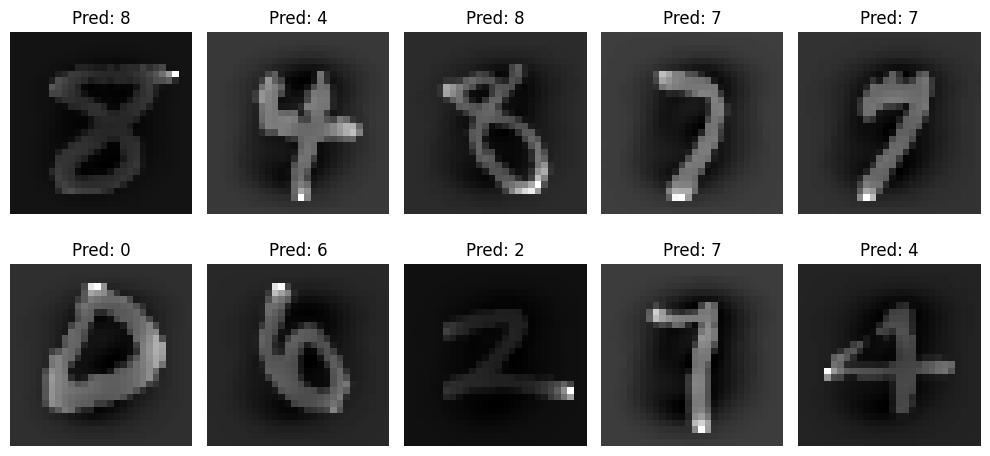

In [2]:
# ==============================
# MNIST Digit Classification using KNN
# ==============================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ------------------------------
# 1. Load Dataset
# ------------------------------
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)

# ------------------------------
# 2. Normalize Data
# ------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ------------------------------
# 3. Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ------------------------------
# 4. Speed Optimization (Optional)
# ------------------------------
# KNN is slow, so we reduce training size
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

# ------------------------------
# 5. Train KNN Model
# ------------------------------
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

print("Training KNN model...")
knn.fit(X_train_small, y_train_small)

# ------------------------------
# 6. Make Predictions
# ------------------------------
print("Predicting...")
y_pred = knn.predict(X_test)

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ------------------------------
# 8. Visualize Predictions
# ------------------------------
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()